# 🔬 Hamiltonians & the Ising Model — The Language of Quantum Optimization

> *"The Hamiltonian is the energy operator — it tells you everything about how a quantum system behaves."*

## What you will gain

| # | Skill |
|---|-------|
| 1 | Understand Hamiltonians as Hermitian energy operators with eigenvalue equation Ĥ\|ψ⟩ = E\|ψ⟩ |
| 2 | Build and diagonalise the classical Ising Hamiltonian for spin chains |
| 3 | Encode binary optimisation problems (Number Partitioning, MaxCut) as diagonal Hamiltonians |
| 4 | Apply the variational principle ⟨ψ\|Ĥ\|ψ⟩ ≥ E₀ to approximate ground states |
| 5 | Analyse energy spectra and gaps to gauge problem difficulty |

## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator

backend = BasicSimulator()
SHOTS = 4096
SEED = 42

# ── Pauli matrices ──
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def multi_kron(*mats):
    """Tensor product of an arbitrary number of matrices."""
    result = mats[0]
    for m in mats[1:]:
        result = np.kron(result, m)
    return result


def build_ising_chain(n, J, h):
    """Build an n-spin Ising chain: H = -J sum Z_i Z_{i+1} - h sum Z_i.

    Uses Qiskit qubit ordering (qubit 0 = LSB).
    """
    dim = 2 ** n
    H = np.zeros((dim, dim), dtype=complex)
    for i in range(n - 1):
        ops = [I2] * n
        ops[n - 1 - i] = Z
        ops[n - 1 - (i + 1)] = Z
        H -= J * multi_kron(*ops)
    for i in range(n):
        ops = [I2] * n
        ops[n - 1 - i] = Z
        H -= h * multi_kron(*ops)
    return H


print("Setup complete \u2705")
print(f"Backend: {backend.name}")

Setup complete ✅
Backend: basic_simulator


## Part I — What Is a Hamiltonian?

A **Hamiltonian** $\hat{H}$ is a Hermitian operator whose eigenvalues are the **energy levels** of a quantum system.

### Eigenvalue equation

$$\hat{H}\,|\psi\rangle = E\,|\psi\rangle$$

- **Eigenvalues** $E$ — allowed energies.
- **Eigenstates** $|\psi\rangle$ — stationary states; they do not change (up to a phase) under time evolution.

### Time evolution (link to notebook 102)

A Hamiltonian generates dynamics through the unitary

$$U(t) = e^{-i\hat{H}t}$$

Every unitary we studied in notebook 102 can be viewed as time evolution under *some* Hamiltonian.

### Hermiticity

Physical observables must be real, so Hamiltonians must satisfy

$$H = H^{\dagger}$$

which guarantees real eigenvalues and an orthonormal eigenbasis.

### The Pauli operators

The three Pauli matrices form a basis for all single-qubit Hermitian (traceless) operators:

$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad
  Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad
  Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

Key properties:
- Each squares to identity: $X^2 = Y^2 = Z^2 = I$
- Eigenvalues of every Pauli are $\pm 1$
- They anti-commute: $XY = -YX$, etc.

**Multi-qubit systems** use the tensor product $\otimes$.  For example, $Z_0 Z_1 = Z \otimes Z$ acts on two qubits.  Any Hamiltonian on $n$ qubits can be decomposed into a sum of **Pauli strings** — tensor products of $\{I, X, Y, Z\}^{\otimes n}$.

In [12]:
# Verify Pauli matrices as Hamiltonians
print("=== Pauli-Z as a Hamiltonian ===")
print(f"Z =\n{Z.real}")

assert np.allclose(Z, Z.conj().T), "Z not Hermitian"
print("Hermitian: \u2705")

evals_z, evecs_z = np.linalg.eigh(Z.real)
print(f"Eigenvalues: {evals_z}")
print(f"Ground state energy: {evals_z}")
print(f"Ground state |0\u27e9: {evecs_z[:, 1]}")
print(f"Ground state |1\u27e9: {evecs_z[:, 0]}")
assert np.allclose(sorted(evals_z), [-1, 1])

print("\n=== Pauli-X as a Hamiltonian ===")
print(f"X =\n{X.real}")
assert np.allclose(X, X.conj().T), "X not Hermitian"
evals_x, evecs_x = np.linalg.eigh(X.real)
print(f"Eigenvalues: {evals_x}")
print(f"Ground state energy: {evals_x}")
print(f"Ground state |0\u27e9: {evecs_x[:, 1]}")
print(f"Ground state |1\u27e9: {evecs_x[:, 0]}")
assert np.allclose(sorted(evals_x), [-1, 1])

print("\n=== Pauli-Y ===")
assert np.allclose(Y, Y.conj().T), "Y not Hermitian"
evals_y, evecs_y = np.linalg.eigh(Y)
print(f"Eigenvalues: {evals_y}")
print(f"Ground state energy: {evals_y}")
print(f"Ground state |0\u27e9: {evecs_y[:, 1]}")
print(f"Ground state |1\u27e9: {evecs_y[:, 0]}")
assert np.allclose(sorted(evals_y.real), [-1, 1])

print("All Pauli matrices verified as Hermitian with eigenvalues \u00b11 \u2705")

=== Pauli-Z as a Hamiltonian ===
Z =
[[ 1.  0.]
 [ 0. -1.]]
Hermitian: ✅
Eigenvalues: [-1.  1.]
Ground state energy: [-1.  1.]
Ground state |0⟩: [1. 0.]
Ground state |1⟩: [0. 1.]

=== Pauli-X as a Hamiltonian ===
X =
[[0. 1.]
 [1. 0.]]
Eigenvalues: [-1.  1.]
Ground state energy: [-1.  1.]
Ground state |0⟩: [0.70710678 0.70710678]
Ground state |1⟩: [-0.70710678  0.70710678]

=== Pauli-Y ===
Eigenvalues: [-1.  1.]
Ground state energy: [-1.  1.]
Ground state |0⟩: [-0.70710678+0.j          0.        -0.70710678j]
Ground state |1⟩: [-0.70710678+0.j          0.        +0.70710678j]
All Pauli matrices verified as Hermitian with eigenvalues ±1 ✅


## Part II — The Classical Ising Model

Proposed by **Wilhelm Lenz** (1920) and solved in 1-D by his student **Ernst Ising** (1925), the Ising model is the fundamental framework for interacting spin systems.

### Hamiltonian

$$H_{\text{Ising}} = -\sum_{\langle i,j \rangle} J_{ij}\, Z_i Z_j \;-\; \sum_i h_i\, Z_i$$

| Symbol | Meaning |
|--------|---------|
| $Z_i$ | Pauli-Z on spin $i$ (eigenvalue $+1$ for $\|0\rangle$, $-1$ for $\|1\rangle$) |
| $J_{ij}$ | Coupling strength between spins $i$ and $j$ |
| $h_i$ | External magnetic field on spin $i$ |

- **Ground state** = lowest eigenvalue = minimum-energy spin configuration.
- Because every term is diagonal in the $Z$ basis, $H_{\text{Ising}}$ is a **diagonal matrix** — its eigenvalues are simply the diagonal entries.

In [13]:
n = 3
J, h_field = 1.0, 0.5

H_ising = build_ising_chain(n, J, h_field)

assert np.allclose(H_ising, H_ising.conj().T), "Ising H not Hermitian"
assert np.allclose(H_ising, np.diag(np.diag(H_ising))), "Ising H should be diagonal"

eigenvalues = np.sort(np.linalg.eigvalsh(H_ising.real))
diag = np.real(np.diag(H_ising))

print(f"3-spin Ising chain  (J={J}, h={h_field})")
print(f"{'State':>8} {'Spins':>8} {'Energy':>8}")
print("-" * 28)
for idx in range(2 ** n):
    bits = format(idx, f"0{n}b")
    spins = "".join("\u2191" if b == "0" else "\u2193" for b in bits)
    print(f" |{bits}\u27e9  {spins:>8} {diag[idx]:>8.2f}")

gs_energy = eigenvalues[0]
brute_min = np.min(diag)
assert abs(gs_energy - brute_min) < 1e-9
assert abs(gs_energy - (-3.5)) < 1e-9, f"Expected -3.5, got {gs_energy}"
print(f"\nGround state energy: {gs_energy:.4f}")
print(f"Ground state |000\u27e9 (all spins aligned with field) \u2705")

3-spin Ising chain  (J=1.0, h=0.5)
   State    Spins   Energy
----------------------------
 |000⟩       ↑↑↑    -3.50
 |001⟩       ↑↑↓    -0.50
 |010⟩       ↑↓↑     1.50
 |011⟩       ↑↓↓     0.50
 |100⟩       ↓↑↑    -0.50
 |101⟩       ↓↑↓     2.50
 |110⟩       ↓↓↑     0.50
 |111⟩       ↓↓↓    -0.50

Ground state energy: -3.5000
Ground state |000⟩ (all spins aligned with field) ✅


C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:18: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:18: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:18: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("ising_3spin_spectrum.png", dpi=100, bbox_inches="tight")
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_35612\2899855638.py:19: UserWarning: Glyph 8321 (

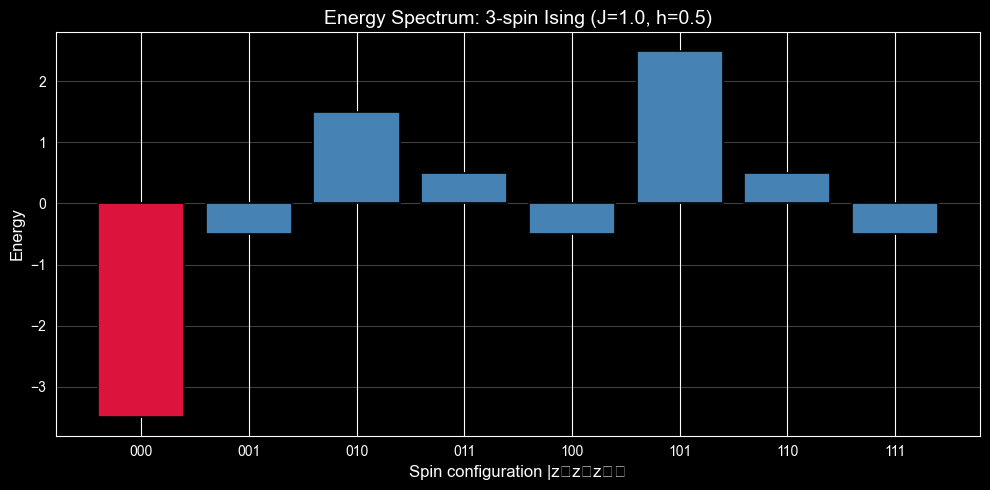

Energy spectrum plot complete ✅


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
states = [format(i, f"0{n}b") for i in range(2 ** n)]
colors = ["crimson" if abs(diag[i] - gs_energy) < 1e-9 else "steelblue"
          for i in range(2 ** n)]

ax.bar(states, diag, color=colors, edgecolor="black", linewidth=1.2)

for i in range(2 ** n):
    if abs(diag[i] - gs_energy) < 1e-9:
        ax.annotate("Ground\nstate", (i, diag[i]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold", color="crimson")

ax.set_xlabel("Spin configuration |z\u2082z\u2081z\u2080\u27e9", fontsize=12)
ax.set_ylabel("Energy", fontsize=12)
ax.set_title(f"Energy Spectrum: 3-spin Ising (J={J}, h={h_field})", fontsize=14)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("ising_3spin_spectrum.png", dpi=100, bbox_inches="tight")
plt.show()

assert abs(np.min(diag) - gs_energy) < 1e-9
print("Energy spectrum plot complete \u2705")

### Ferromagnetic vs Antiferromagnetic

| Regime | Coupling | Ground state preference |
|--------|----------|------------------------|
| **Ferromagnetic** | $J > 0$ | Neighbouring spins **align** ($\uparrow\uparrow$ or $\downarrow\downarrow$) |
| **Antiferromagnetic** | $J < 0$ | Neighbouring spins **anti-align** ($\uparrow\downarrow$ or $\downarrow\uparrow$) |
| **Frustrated** | Mixed signs | No single configuration satisfies all couplings — leads to degeneracy |

The external field $h$ competes with the coupling: large $|h|$ forces all spins to align with the field regardless of $J$.

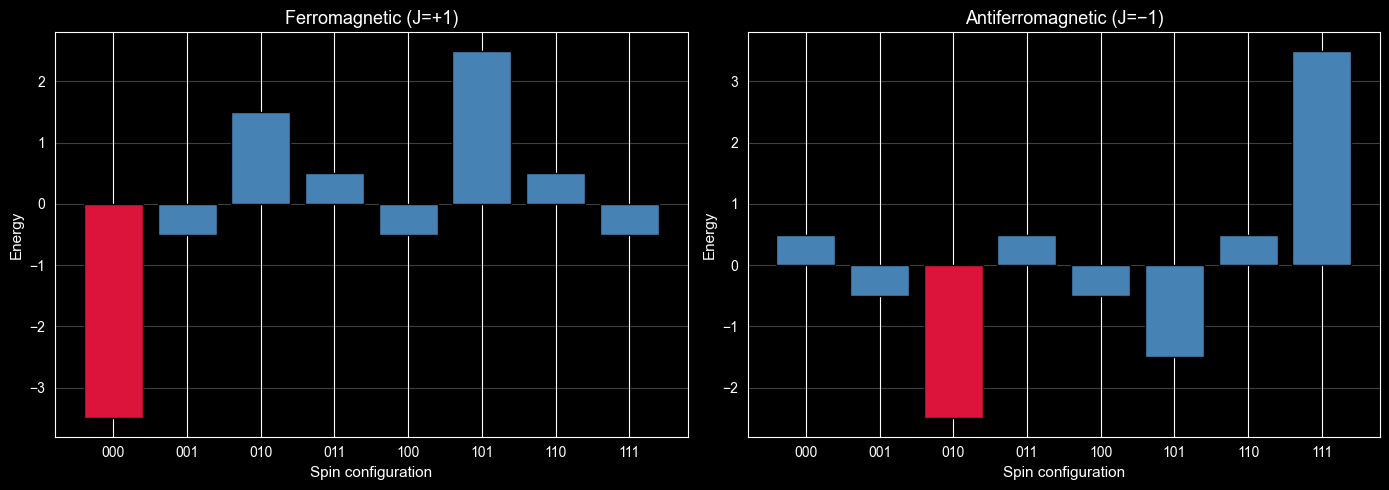

Ferromagnetic ground state energy:     -3.50
Antiferromagnetic ground state energy: -2.50
Comparison complete ✅


In [15]:
H_ferro = build_ising_chain(3, J=1.0, h=0.5)
H_anti  = build_ising_chain(3, J=-1.0, h=0.5)

diag_f = np.real(np.diag(H_ferro))
diag_a = np.real(np.diag(H_anti))
labels = [format(i, "03b") for i in range(8)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, d, title in [(axes[0], diag_f, "Ferromagnetic (J=+1)"),
                      (axes[1], diag_a, "Antiferromagnetic (J=\u22121)")]:
    gs = np.min(d)
    cols = ["crimson" if abs(e - gs) < 1e-9 else "steelblue" for e in d]
    ax.bar(labels, d, color=cols, edgecolor="black", linewidth=1.0)
    ax.set_xlabel("Spin configuration", fontsize=11)
    ax.set_ylabel("Energy", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("ferro_vs_anti.png", dpi=100, bbox_inches="tight")
plt.show()

assert abs(np.min(diag_f) - (-3.5)) < 1e-9
print(f"Ferromagnetic ground state energy:     {np.min(diag_f):.2f}")
print(f"Antiferromagnetic ground state energy: {np.min(diag_a):.2f}")
print("Comparison complete \u2705")

### Phase diagram intuition

The ratio $|h / J|$ controls the physics:

- $|h| \ll |J|$: coupling dominates → ordered phase (ferro or antiferro).
- $|h| \gg |J|$: field dominates → all spins align with the field (paramagnetic phase).
- $|h| \approx |J|$: competition → the energy gap shrinks and the ground state becomes sensitive to small perturbations.

In the **quantum** (transverse-field) Ising model, this competition produces a genuine **quantum phase transition**, but even the classical model captures the essential intuition.

## Part III — From Classical Problems to Quantum Hamiltonians

### The key insight

Any **binary optimisation** problem — minimise $C(\mathbf{z})$ over $\mathbf{z} \in \{0,1\}^n$ — can be encoded as a quantum Hamiltonian:

1. Map each classical bit $z_i \in \{0,1\}$ to a qubit via $Z_i$:
   $Z|0\rangle = +|0\rangle, \quad Z|1\rangle = -|1\rangle$
   so $z_i = (1 - Z_i) / 2$.

2. Rewrite $C(\mathbf{z})$ in terms of $Z_i$ operators → obtain **cost Hamiltonian** $\hat{C}$.

3. $\hat{C}$ is diagonal in the computational basis; its eigenvalues **are** the costs.

4. **Finding the ground state of $\hat{C}$ = solving the optimisation problem.**

In [ ]:
# Number Partitioning: split S into two subsets with equal sums
S = np.array([3, 1, 4, 2])
n_part = len(S)
dim_part = 2 ** n_part

# Cost: C(x) = (sum_i s_i (1-2x_i))^2  — squared difference of subset sums
costs = np.zeros(dim_part)
for idx in range(dim_part):
    bits = [(idx >> (n_part - 1 - k)) & 1 for k in range(n_part)]
    diff = sum(S[k] * (1 - 2 * bits[k]) for k in range(n_part))
    costs[idx] = diff ** 2

H_part = np.diag(costs.astype(complex))

assert np.allclose(H_part, np.diag(np.diag(H_part))), "Should be diagonal"
assert np.allclose(H_part, H_part.conj().T), "Should be Hermitian"

min_cost = np.min(costs)
optimal = [format(i, f"0{n_part}b") for i in range(dim_part)
           if abs(costs[i] - min_cost) < 1e-9]

print(f"Number set: S = {list(S)},  total = {sum(S)}")
print(f"\n{'State':>7} {'A':>12} {'B':>12} {'Cost':>6}")
print("-" * 42)
for idx in range(dim_part):
    bits = format(idx, f"0{n_part}b")
    A = [int(S[k]) for k in range(n_part) if bits[k] == "0"]
    B = [int(S[k]) for k in range(n_part) if bits[k] == "1"]
    tag = " \u2190 optimal" if abs(costs[idx] - min_cost) < 1e-9 else ""
    print(f" |{bits}\u27e9 {str(A):>12} {str(B):>12} {costs[idx]:>6.0f}{tag}")

assert abs(min_cost) < 1e-9, "Perfect partition should exist"
assert len(optimal) == 2, "Expect exactly 2 optimal states"
print(f"\nMinimum cost: {min_cost:.0f}  (perfect partition)")
print(f"Optimal states: {optimal}")
print(f"Number partitioning verified \u2705")

In [ ]:
# MaxCut on a triangle graph (3 nodes, 3 edges)
n_mc = 3
edges = [(0, 1), (1, 2), (0, 2)]
dim_mc = 2 ** n_mc

# C = sum_{(i,j)} (I - Z_i Z_j) / 2
H_maxcut = np.zeros((dim_mc, dim_mc), dtype=complex)
for (i, j) in edges:
    ops_I  = [I2] * n_mc
    ops_ZZ = [I2] * n_mc
    ops_ZZ[n_mc - 1 - i] = Z
    ops_ZZ[n_mc - 1 - j] = Z
    H_maxcut += (multi_kron(*ops_I) - multi_kron(*ops_ZZ)) / 2

assert np.allclose(H_maxcut, np.diag(np.diag(H_maxcut))), "MaxCut H should be diagonal"

mc_costs = np.real(np.diag(H_maxcut))
expected = [0, 2, 2, 2, 2, 2, 2, 0]
assert np.allclose(mc_costs, expected), f"Expected {expected}, got {list(mc_costs)}"

print("MaxCut on triangle graph")
print(f"Edges: {edges}\n")
for idx in range(dim_mc):
    bits = format(idx, f"0{n_mc}b")
    print(f"  |{bits}\u27e9  cut = {mc_costs[idx]:.0f}")
print(f"\nMaximum cut: {np.max(mc_costs):.0f}")
assert abs(np.max(mc_costs) - 2.0) < 1e-9
print("MaxCut verified \u2705")
print("\n\u27a1 Full MaxCut treatment with QAOA in notebook 201")

### The general encoding pattern

| Optimisation Problem | Hamiltonian | Ground-state meaning |
|----------------------|-------------|----------------------|
| Number Partitioning  | $\hat{C} = \bigl(\sum_i s_i Z_i\bigr)^2$ | Equal-sum partition (cost = 0) |
| MaxCut               | $\hat{C} = \sum_{(i,j)\in E} \frac{I - Z_i Z_j}{2}$ | Maximum number of cut edges |
| Max-SAT, Graph Colouring, TSP … | Various Pauli-string sums | Problem-specific optimum |

**Key takeaway:** any cost function over binary variables maps to a **diagonal** Hamiltonian whose eigenvalues are the costs.  The ground state encodes the optimal solution.

## Part IV — The Variational Principle

For **any** quantum state $|\psi\rangle$:

$$\langle\psi|\,\hat{H}\,|\psi\rangle \;\geq\; E_{\text{ground}}$$

This means the expectation value of the energy can never drop below the true ground-state energy.

### Variational method

1. Choose a **parameterised ansatz** $|\psi(\theta)\rangle$ (a circuit with tunable gates).
2. Sweep (or optimise) $\theta$ to **minimise** $\langle\psi(\theta)|\,\hat{H}\,|\psi(\theta)\rangle$.
3. The minimum you find is an **upper bound** on $E_{\text{ground}}$.

This is the foundation of:
- **VQE** (Variational Quantum Eigensolver) — general Hamiltonians, hardware-efficient ansatz.
- **QAOA** (Quantum Approximate Optimisation Algorithm) — combinatorial problems, problem-specific ansatz.

In [ ]:
# 2-qubit Ising with J=1, h=0.3
J_var, h_var = 1.0, 0.3
H_var = build_ising_chain(2, J_var, h_var)

evals_var = np.sort(np.linalg.eigvalsh(H_var.real))
E_exact = evals_var[0]
print(f"Exact ground state energy: {E_exact:.4f}")

# Ansatz: Ry(theta) on each qubit  (product-state ansatz)
thetas = np.linspace(0, 2 * np.pi, 200)
expectations = []
for theta in thetas:
    qc = QuantumCircuit(2)
    qc.ry(theta, 0)
    qc.ry(theta, 1)
    sv = Statevector(qc)
    psi = sv.data
    E = np.real(psi.conj() @ H_var @ psi)
    expectations.append(E)

expectations = np.array(expectations)
E_var_min = np.min(expectations)
theta_opt = thetas[np.argmin(expectations)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thetas, expectations, "b-", linewidth=2, label="\u27e8H\u27e9(\u03b8)")
ax.axhline(E_exact, color="r", linestyle="--", linewidth=1.5,
           label=f"Exact E\u2080 = {E_exact:.2f}")
ax.plot(theta_opt, E_var_min, "r*", markersize=15,
        label=f"Variational min = {E_var_min:.2f}")
ax.set_xlabel("\u03b8  (radians)", fontsize=12)
ax.set_ylabel("\u27e8H\u27e9", fontsize=12)
ax.set_title("Variational Energy Landscape: 2-qubit Ising", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("variational_landscape.png", dpi=100, bbox_inches="tight")
plt.show()

assert abs(E_var_min - E_exact) < 0.01, (
    f"Variational min {E_var_min:.4f} too far from exact {E_exact:.4f}")
print(f"\nVariational minimum: {E_var_min:.4f}  at \u03b8 = {theta_opt:.4f}")
print(f"Exact ground state:  {E_exact:.4f}")
print(f"Variational principle verified \u2705")

### Connection to quantum algorithms

| Algorithm | Hamiltonian type | Ansatz | Optimiser |
|-----------|-----------------|--------|-----------|
| **VQE** | General (molecular, condensed-matter) | Hardware-efficient layers | Classical (COBYLA, L-BFGS-B) |
| **QAOA** | Diagonal cost Hamiltonian (combinatorial) | Alternating $e^{-i\gamma \hat{C}}$ and $e^{-i\beta \hat{B}}$ | Classical |

Both algorithms rely on the variational principle: *no trial state can beat the true ground-state energy*.

➡ See **notebook 201** for a full QAOA implementation on MaxCut.

## Part V — Spectral Analysis & Visualisation

### Why energy spectra matter

The **energy gap**

$$\Delta E = E_1 - E_0$$

(first excited state energy minus ground state energy) is a key indicator:

| Gap size | Implication |
|----------|-------------|
| **Large** $\Delta E$ | Ground state is well separated → easy to identify and prepare |
| **Small** $\Delta E$ | Ground state is nearly degenerate → problem is computationally hard |
| $\Delta E \to 0$ | Signals a **phase transition** or **level crossing** |

In [ ]:
# Energy gap vs external field for a 4-spin Ising chain
n_spec = 4
J_spec = 1.0
h_values = np.linspace(0.01, 3.0, 50)
gaps = []

for hv in h_values:
    H_temp = build_ising_chain(n_spec, J_spec, hv)
    ev = np.sort(np.linalg.eigvalsh(H_temp.real))
    # Gap = first energy strictly above the ground-state manifold
    e0 = ev[0]
    e1 = ev[np.argmax(ev > e0 + 1e-12)]
    gaps.append(e1 - e0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h_values, gaps, "b-o", markersize=3, linewidth=1.5)
axes[0].set_xlabel("External field h", fontsize=12)
axes[0].set_ylabel("Energy gap  \u0394E = E\u2081 \u2212 E\u2080", fontsize=12)
axes[0].set_title(f"Energy Gap: {n_spec}-spin Ising (J={J_spec})", fontsize=14)
axes[0].grid(axis="y", alpha=0.25)

h_show = 1.0
H_show = build_ising_chain(n_spec, J_spec, h_show)
evals_show = np.sort(np.linalg.eigvalsh(H_show.real))
axes[1].bar(range(len(evals_show)), evals_show,
            color="steelblue", edgecolor="black")
axes[1].set_xlabel("Energy level index", fontsize=12)
axes[1].set_ylabel("Energy", fontsize=12)
axes[1].set_title(f"Full Spectrum: {n_spec}-spin Ising (h={h_show})", fontsize=14)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("spectral_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

assert all(g > -1e-9 for g in gaps), "Energy gap must be non-negative"
print(f"Gap range: [{min(gaps):.4f}, {max(gaps):.4f}]")
print(f"Spectral analysis complete \u2705")

In [ ]:
# Prepare approximate ground state and verify via measurement
n_ver = 3
J_ver, h_ver = 1.0, 0.5
H_ver = build_ising_chain(n_ver, J_ver, h_ver)
E_ground_ver = np.sort(np.linalg.eigvalsh(H_ver.real))[0]

# Circuit with small rotations (near the ground state |000>)
qc_ver = QuantumCircuit(n_ver)
qc_ver.ry(0.3, 0)
qc_ver.ry(0.2, 1)
qc_ver.ry(0.1, 2)

sv_ver = Statevector(qc_ver)
psi_ver = sv_ver.data
E_approx = np.real(psi_ver.conj() @ H_ver @ psi_ver)

print(f"Exact ground state energy:   {E_ground_ver:.4f}")
print(f"Approx. state energy:        {E_approx:.4f}")
assert E_approx >= E_ground_ver - 1e-9, "Variational principle violated!"
print(f"Variational bound satisfied:  {E_approx:.4f} \u2265 {E_ground_ver:.4f} \u2705")

# Measure
qc_meas = qc_ver.copy()
qc_meas.measure_all()
qc_t = transpile(qc_meas, backend)
result = backend.run(qc_t, shots=SHOTS, seed_simulator=SEED).result()
counts = result.get_counts()

print(f"\nMeasurement results (top 5):")
for state, cnt in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  |{state}\u27e9: {cnt}/{SHOTS}  ({cnt/SHOTS:.3f})")

most_probable = max(counts, key=counts.get)
assert most_probable == "000", f"Expected |000\u27e9, got |{most_probable}\u27e9"
print(f"\nMost probable outcome: |{most_probable}\u27e9 = ground state \u2705")

# Empirical energy
diag_ver = np.real(np.diag(H_ver))
E_emp = sum(diag_ver[int(s, 2)] * c for s, c in counts.items()) / SHOTS
print(f"Empirical energy:  {E_emp:.4f}")
print(f"Exact expectation: {E_approx:.4f}")
assert abs(E_emp - E_approx) < 0.2, "Empirical energy too far from exact"
print(f"Measurement verification complete \u2705")

### Time evolution from the Hamiltonian

Since $H_{\text{Ising}}$ is diagonal, its time-evolution operator is simply:

$$U(t) = e^{-iHt} = \text{diag}\!\bigl(e^{-iE_0 t},\; e^{-iE_1 t},\; \ldots\bigr)$$

For a diagonal Hamiltonian, time evolution only adds **phases** — it does not change measurement probabilities.  Real quantum dynamics (population transfer between states) requires **off-diagonal** terms, such as the transverse-field Ising model $H = -J\sum Z_i Z_j - g\sum X_i$.

Nevertheless, verifying that $U(t)$ is unitary ($U^{\dagger}U = I$) and preserves probabilities connects back to the unitarity principle from **notebook 102**.

In [ ]:
# Time evolution: U(t) = exp(-i H t)
t_evo = 1.0
H_evo = build_ising_chain(2, 1.0, 0.5)
diag_H_evo = np.real(np.diag(H_evo))

U_t = np.diag(np.exp(-1j * diag_H_evo * t_evo))

# Verify unitarity
assert np.allclose(U_t.conj().T @ U_t, np.eye(len(diag_H_evo))), "U(t) not unitary!"
print(f"U(t={t_evo}) is unitary: U\u2020 U = I \u2705")

# Apply to |00>
psi_0 = np.array([1, 0, 0, 0], dtype=complex)
psi_t = U_t @ psi_0

print(f"\nInitial state |00\u27e9 probabilities: {np.abs(psi_0)**2}")
print(f"Evolved  state       probabilities: {np.round(np.abs(psi_t)**2, 10)}")
assert np.allclose(np.abs(psi_t) ** 2, np.abs(psi_0) ** 2)
print("Probabilities preserved (diagonal H \u2192 phase-only evolution) \u2705")

# Show the acquired phase
phase = np.angle(psi_t[0])
print(f"\nAcquired phase: {phase:.4f} rad  (= -E\u2080 t = {-diag_H_evo[0]*t_evo:.4f})")
assert abs(phase - (-diag_H_evo[0] * t_evo)) < 1e-9
print("Phase matches -E\u2080 t \u2705")

## Takeaways

| Concept | Key Insight |
|---------|-------------|
| **Hamiltonian** | Hermitian operator whose eigenvalues are energies; $\hat{H}|\psi\rangle = E|\psi\rangle$ |
| **Time evolution** | Unitary $U(t) = e^{-i\hat{H}t}$ — Hamiltonians generate dynamics |
| **Pauli operators** | $X, Y, Z$ form a basis for all single-qubit Hermitian operators |
| **Ising model** | $H = -\sum J_{ij} Z_i Z_j - \sum h_i Z_i$ — universal framework for spin systems |
| **Ground state** | Lowest eigenvalue = optimal solution to the encoded optimisation problem |
| **Problem encoding** | Any binary optimisation → diagonal Hamiltonian; eigenvalues = costs |
| **Variational principle** | $\langle\psi|\hat{H}|\psi\rangle \geq E_{\text{ground}}$ — foundation of VQE and QAOA |
| **Energy gap** | $\Delta E = E_1 - E_0$; large gap → easy, small gap → computationally hard |

---

**Next →** Notebook **201** applies QAOA to solve MaxCut on real graphs using the cost Hamiltonians built here.